<a href="https://colab.research.google.com/github/TaeHyeon-Kim00/26-2-DIP-TaehyeonKim/blob/main/notebook_2026/Lab00_ImageLoad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Image file(s)
- 직접 찍은 본인이 좋아하는 사진을 업로드하기.
- matplotlib의 imread 이용하여 image data로 불러오기.
- Image의 데이터타입과 공간해상도를 확인하기.
- matplotlib의 imshow로 image를 display하고, 적절한 제목을 붙여주기.

uint8 (4032, 2268, 3)


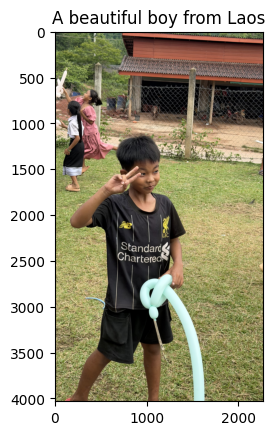

In [17]:
I = plt.imread('IMG_8921.jpeg')
print(I.dtype, I.shape)
plt.imshow(I)
plt.title('A beautiful boy from Laos')
plt.show()

- Image file의 metadata를 확인하기

In [18]:
from PIL import Image
from PIL.ExifTags import TAGS

In [19]:
I = Image.open('IMG_8921.jpeg')
exifdata = I.getexif()
for tag_id in exifdata:
    tag = TAGS.get(tag_id, tag_id)
    data = exifdata.get(tag_id)
    print(f"{tag:25}: {data}")

GPSInfo                  : 2896
ResolutionUnit           : 2
ExifOffset               : 244
Make                     : Apple
Model                    : iPhone 17 Pro Max
Software                 : 26.5.2
Orientation              : 1
DateTime                 : 2026:07:14 17:32:13
YCbCrPositioning         : 1
XResolution              : 72.0
YResolution              : 72.0
HostComputer             : iPhone 17 Pro Max


# 2. DICOM

In [3]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 21.1 MB/s eta 0:00:00


In [4]:
import pydicom

In [5]:
dcm = pydicom.dcmread('IM-0001-0001.dcm')

In [6]:
print("modality:",dcm.Modality)
print("hospital:",dcm.InstitutionName)
print("voxelsize:",dcm.PixelSpacing)
print("slice thickness:",dcm.SliceThickness)

modality: MR
hospital: HUFS
voxelsize: [0.381944, 0.381944]
slice thickness: 70


In [7]:
f = dcm.pixel_array
print(f.shape)
print("Lmin : ",np.min(f))
print("Lmax : ",np.max(f))

(576, 522)
Lmin :  0
Lmax :  1574


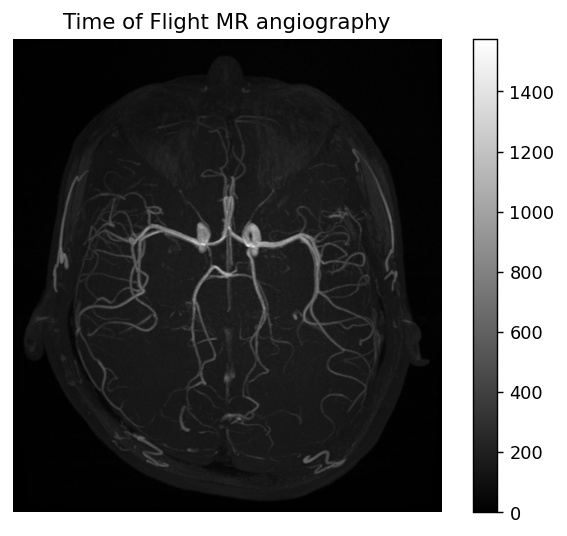

In [8]:
plt.figure(dpi=128)
plt.imshow(f,vmin=np.min(f),vmax=np.max(f),cmap='gray')
plt.colorbar()
plt.axis('off')
plt.title('Time of Flight MR angiography')
plt.show()

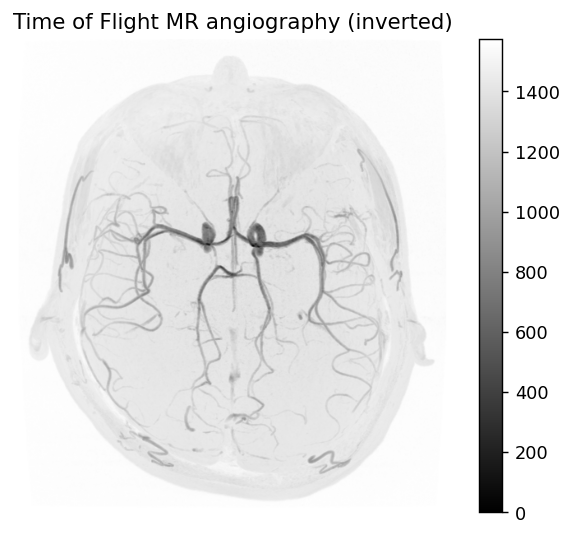

In [9]:
f_inv = np.max(f)-f
plt.figure(dpi=128)
plt.imshow(f_inv,vmin=np.min(f_inv),vmax=np.max(f_inv),cmap='gray')
plt.colorbar()
plt.axis('off')
plt.title('Time of Flight MR angiography (inverted)')
plt.show()

# 3. Nifti (nii or nii.gz)

In [10]:
!pip install nibabel

In [11]:
import nibabel as nib

In [12]:
h = nib.load('volume-covid19-A-0700_day000.nii.gz')
print(h.shape)

FileNotFoundError: No such file or no access: 'volume-covid19-A-0700_day000.nii.gz'

In [ ]:
print(h.header)

In [ ]:
ct_base = h.get_fdata()
print(ct_base.dtype, ct_base.shape)
print(np.min(ct_base),np.max(ct_base))

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(ct_base[:,:,30],vmin=-1500,vmax=500,cmap='gray')
plt.subplot(132)
plt.imshow(ct_base[:,:,40],vmin=-1500,vmax=500,cmap='gray')
plt.subplot(133)
plt.imshow(ct_base[:,:,50],vmin=-1500,vmax=500,cmap='gray')
plt.tight_layout()
plt.show()

- day015 및 day015를 day000에 registration한 파일을 각각 불러오기.
- day000을 포함하여 세 ct영상데이터의 동일한 단면을 display하여 비교하기.

In [ ]:
ct_FU = nib.load('volume-covid19-A-0700_day015.nii.gz').get_fdata()
ct_FU_reg = nib.load('volume-covid19-A-0700_day015-reg_to_day000.nii.gz').get_fdata()

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(ct_base[:,:,30],vmin=-1500,vmax=500,cmap='gray')
plt.subplot(132)
plt.imshow(ct_FU[:,:,30],vmin=-1500,vmax=500,cmap='gray')
plt.subplot(133)
plt.imshow(ct_FU_reg[:,:,30],vmin=-1500,vmax=500,cmap='gray')
plt.tight_layout()
plt.show()